In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
np.random.seed(42)
%matplotlib inline

ModuleNotFoundError: No module named 'pandas'

##1. Exploration des donnees

In [3]:
df = pd.read_csv("/content/african_crises.csv")
df.head()

NameError: name 'pd' is not defined

In [4]:
print(df.shape)
print(df.dtypes)
print("missing values :", df.isnull().sum().sum())
print("country :", df['country'].nunique)

NameError: name 'df' is not defined

In [ ]:
df['banking_crisis'] = df['banking_crisis'].map({'crisis': 1, 'no_crisis': 0})
df[['exch_usd','inflation_annual_cpi']].describe()

,exch_usd,inflation_annual_cpi
count,1059.000000,1.059000e+03
mean,43.140831,2.084889e+04
std,111.475380,6.757274e+05
min,0.000000,-2.850214e+01
25%,0.195350,2.086162e+00
50%,0.868400,5.762330e+00
75%,8.462750,1.164405e+01
max,744.306139,2.198970e+07


##2. Target distribution and correlations

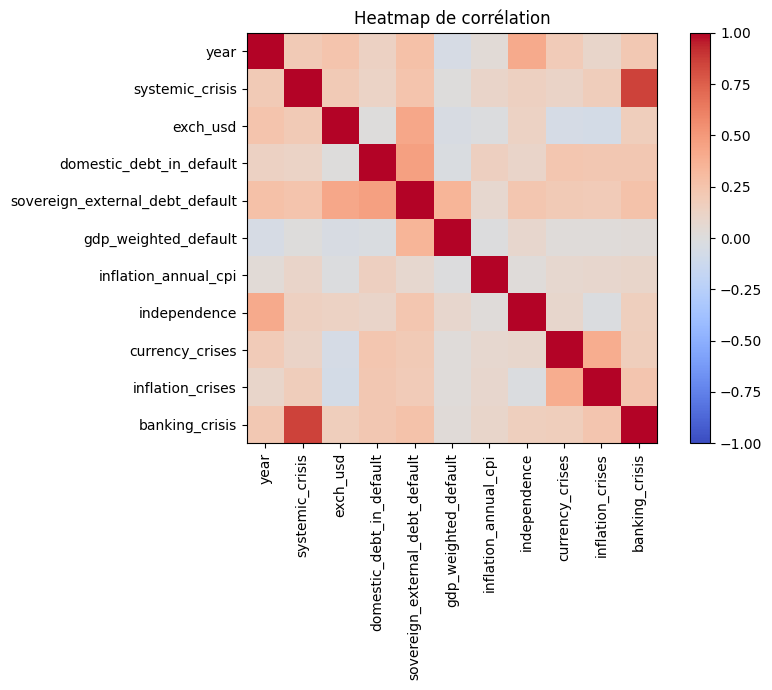

In [ ]:
corr = df.drop(columns=['case','cc3','country']).corr(numeric_only=True)
plt.figure(figsize=(9,7))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Heatmap de corrélation')
plt.tight_layout()
plt.show()

In [ ]:
df.nlargest(3, 'inflation_annual_cpi')[['country','year','inflation_annual_cpi']]

,country,year,inflation_annual_cpi
1053,Zimbabwe,2008,2.198970e+07
1052,Zimbabwe,2007,6.627989e+04
143,Angola,1996,4.146010e+03


In [ ]:
df['inflation_annual_cpi'] = np.sign(df['inflation_annual_cpi']) * np.log1p(np.abs(df['inflation_annual_cpi']))

In [ ]:
FEATURES = ['year','systemic_crisis','domestic_debt_in_default','sovereign_external_debt_default',
            'gdp_weighted_default','inflation_annual_cpi','independence','currency_crises',
            'inflation_crises','banking_crisis']
TARGET = 'exch_usd'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(847, 10) (212, 10)


##3. Standardization

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# The target is also standardized to stabilize stochastic gradient descent (SGD)
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1,1)).ravel()

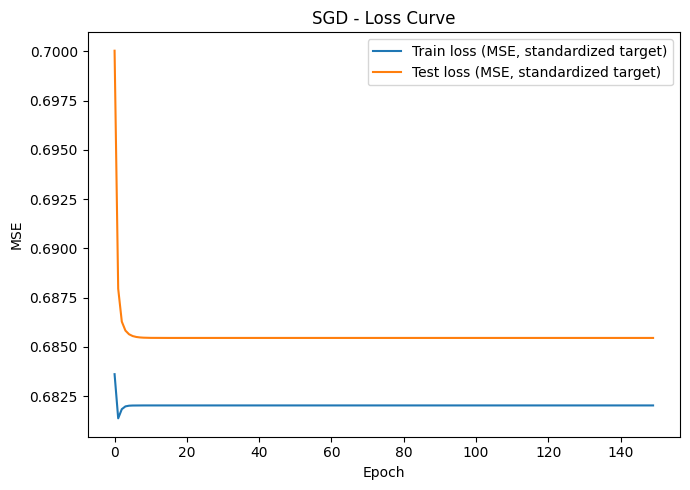

In [ ]:
sgd = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.005, random_state=42, warm_start=True)

train_losses, test_losses = [], []
EPOCHS = 150
for epoch in range(EPOCHS):
    sgd.partial_fit(X_train_s, y_train_s)
    train_losses.append(mean_squared_error(y_train_s, sgd.predict(X_train_s)))
    test_losses.append(mean_squared_error(y_test_s, sgd.predict(X_test_s)))

plt.figure(figsize=(7,5))
plt.plot(train_losses, label='Train loss (MSE, standardized target)')
plt.plot(test_losses, label='Test loss (MSE, standardized target)')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('SGD - Loss Curve')
plt.legend(); plt.tight_layout(); plt.show()